<a href="https://colab.research.google.com/github/lguillon/DatScan-classification-Parkinson_Sept-2026/blob/main/classification_DatScan_tests_qualite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification DatScan — Swin Transformer 3D

Pipeline d'entraînement à partir des volumes déjà prétraités (`final_128`, shape fixe 128×128×128,
intensités non normalisées). Ce notebook part directement du split train/val — le prétraitement
(réorientation, resampling isotrope, crop/pad) est déjà fait et sauvegardé sur Drive.


## 0. Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
!pip install -q monai nibabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.3 MB/s eta 0:00:00


## 1. Configuration

In [3]:
import os
import random
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

DATA_DIR = "/content/drive/MyDrive/Stats/Parkinson"
OUTER_ZIP = f"{DATA_DIR}/DaTScan_data.zip"
OUTPUT_DIR = f"{DATA_DIR}/outputs"
INVENTORY_CSV = f"{OUTPUT_DIR}/image_inventory.csv"
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")
os.makedirs(OUTPUT_DIR, exist_ok=True)

FINAL_DIR = f"{DATA_DIR}/final_128"
LABELS_CSV = f"{DATA_DIR}/train_labels_DatScan.csv"

RANDOM_SEED = 42
IMG_SIZE = (96, 96, 96)     # taille d'entrée du modèle (Resize appliqué depuis 128³)
BATCH_SIZE = 2
N_EPOCHS = 30

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Imports

In [6]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from monai.transforms import Compose, Resize, RandFlip, RandRotate90, RandGaussianNoise, ToTensor
from monai.networks.nets import SwinUNETR
from monai.losses import FocalLoss

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

## 3. Chargement des labels et split train/val

Filtre automatiquement sur les fichiers réellement présents dans `final_128`
(certains volumes ont pu échouer lors du prétraitement).

In [7]:
labels_df = pd.read_csv(LABELS_CSV)
print(labels_df.shape)
labels_df.head()

(1362, 2)


,uid,is_pathologic
0,xaji0y6d,0.0
1,pbhsahxt,0.0
2,hv3a3zmf,0.0
3,8mdd4v30,0.0
4,t9nt3w5u,1.0


In [8]:
available_uids = set(
    f.replace(".nii.gz", "") for f in os.listdir(FINAL_DIR) if f.endswith(".nii.gz")
)
print(f"{len(available_uids)} fichiers disponibles dans final_128")

labels_df_filtered = labels_df.dropna(subset=["is_pathologic"])
labels_df_filtered = labels_df_filtered[labels_df_filtered["uid"].isin(available_uids)].reset_index(drop=True)
print(f"{len(labels_df_filtered)} labels utilisables après filtrage")

filepaths = [os.path.join(FINAL_DIR, f"{uid}.nii.gz") for uid in labels_df_filtered["uid"]]
labels = labels_df_filtered["is_pathologic"].astype(int).values

train_paths, val_paths, train_labels, val_labels = train_test_split(
    filepaths, labels, test_size=0.2, stratify=labels, random_state=RANDOM_SEED
)

print(f"Train: {len(train_paths)}, Val: {len(val_paths)}")
print("Répartition train:", np.bincount(train_labels))
print("Répartition val:", np.bincount(val_labels))

1362 fichiers disponibles dans final_128
1362 labels utilisables après filtrage
Train: 1089, Val: 273
Répartition train: [492 597]
Répartition val: [123 150]


## 4. Dataset et transforms

Pas de normalisation d'intensité (choix volontaire pour l'instant).

In [9]:
class DatScanDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = nib.load(self.filepaths[idx]).get_fdata().astype(np.float32)
        img = np.expand_dims(img, axis=0)  # canal unique -> (1, D, H, W)
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, torch.tensor(label, dtype=torch.long)


train_transforms = Compose([
    Resize(IMG_SIZE),
    RandFlip(prob=0.5, spatial_axis=0),
    RandRotate90(prob=0.5),
    RandGaussianNoise(prob=0.2, std=0.01),
    ToTensor(),
])

val_transforms = Compose([
    Resize(IMG_SIZE),
    ToTensor(),
])

In [10]:
train_ds = DatScanDataset(train_paths, train_labels, transform=train_transforms)
val_ds = DatScanDataset(val_paths, val_labels, transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Vérification avant d'aller plus loin
sample_img, sample_label = train_ds[0]
print("Shape d'un échantillon:", sample_img.shape, "— label:", sample_label)

Shape d'un échantillon: torch.Size([1, 96, 96, 96]) — label: tensor(0)


## 5. Modèle — Swin Transformer 3D

In [15]:
class SwinClassifier(nn.Module):
    def __init__(self, img_size, in_channels=1, num_classes=2):
        super().__init__()
        backbone = SwinUNETR(
            in_channels=in_channels,
            out_channels=num_classes,
            feature_size=48,
        )
        self.encoder = backbone.swinViT
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.head = nn.Linear(768, num_classes)

    def forward(self, x):
        features = self.encoder(x)[-1]
        pooled = self.pool(features).flatten(1)
        return self.head(pooled)

In [17]:
model = SwinClassifier(img_size=IMG_SIZE, num_classes=2).to(device)

## 6. Loss et optimizer

In [19]:
criterion = FocalLoss(gamma=2.0, to_onehot_y=True, use_softmax=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

## 7. Entraînement

Sauvegarde le meilleur modèle (sur val accuracy) sur Drive à chaque amélioration.

In [20]:
# Test sur 2 epochs

N_EPOCHS = 2  # test rapide, tu remonteras à 30 une fois confirmé que ça tourne

In [21]:
BEST_MODEL_PATH = f"{OUTPUT_DIR}/best_swin_model.pt"
best_val_acc = 0.0

for epoch in range(N_EPOCHS):
    model.train()
    train_loss = 0
    for imgs, labels_batch in train_loader:
        imgs, labels_batch = imgs.to(device), labels_batch.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels_batch.unsqueeze(1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels_batch in val_loader:
            imgs, labels_batch = imgs.to(device), labels_batch.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels_batch).sum().item()
            total += labels_batch.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}/{N_EPOCHS} — train loss: {train_loss/len(train_loader):.4f} — val acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  -> Nouveau meilleur modèle sauvegardé (val acc: {val_acc:.4f})")

Epoch 1/2 — train loss: 0.1135 — val acc: 0.5495
  -> Nouveau meilleur modèle sauvegardé (val acc: 0.5495)
Epoch 2/2 — train loss: 0.0922 — val acc: 0.4505


In [22]:
print("Train:", np.bincount(train_labels), "-> proportion classe majoritaire:", max(np.bincount(train_labels)) / len(train_labels))
print("Val:", np.bincount(val_labels), "-> proportion classe majoritaire:", max(np.bincount(val_labels)) / len(val_labels))

Train: [492 597] -> proportion classe majoritaire: 0.5482093663911846
Val: [123 150] -> proportion classe majoritaire: 0.5494505494505495


In [23]:
model.eval()
all_preds = []
with torch.no_grad():
    for imgs, labels_batch in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())

print("Distribution des prédictions:", np.bincount(all_preds))

Distribution des prédictions: [273]


## Modele CNN 3D

In [24]:
class SimpleCNN3D(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(),
            nn.MaxPool3d(2),  # 96 -> 48

            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.MaxPool3d(2),  # 48 -> 24

            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.MaxPool3d(2),  # 24 -> 12

            nn.AdaptiveAvgPool3d(1),
        )
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


cnn_model = SimpleCNN3D(num_classes=2).to(device)
cnn_optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-5)

In [25]:
N_EPOCHS_CNN = 20
best_val_acc_cnn = 0.0
BEST_CNN_PATH = f"{OUTPUT_DIR}/best_cnn_model.pt"

for epoch in range(N_EPOCHS_CNN):
    cnn_model.train()
    train_loss = 0
    for imgs, labels_batch in train_loader:
        imgs, labels_batch = imgs.to(device), labels_batch.to(device)
        cnn_optimizer.zero_grad()
        outputs = cnn_model(imgs)
        loss = criterion(outputs, labels_batch.unsqueeze(1))
        loss.backward()
        cnn_optimizer.step()
        train_loss += loss.item()

    cnn_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels_batch in val_loader:
            imgs, labels_batch = imgs.to(device), labels_batch.to(device)
            outputs = cnn_model(imgs)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels_batch).sum().item()
            total += labels_batch.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}/{N_EPOCHS_CNN} — train loss: {train_loss/len(train_loader):.4f} — val acc: {val_acc:.4f}")

    if val_acc > best_val_acc_cnn:
        best_val_acc_cnn = val_acc
        torch.save(cnn_model.state_dict(), BEST_CNN_PATH)

Epoch 1/20 — train loss: 0.0913 — val acc: 0.5678
Epoch 2/20 — train loss: 0.0875 — val acc: 0.4286
Epoch 3/20 — train loss: 0.0872 — val acc: 0.5751
Epoch 4/20 — train loss: 0.0867 — val acc: 0.5495
Epoch 5/20 — train loss: 0.0852 — val acc: 0.5788
Epoch 6/20 — train loss: 0.0850 — val acc: 0.4799
Epoch 7/20 — train loss: 0.0857 — val acc: 0.5897
Epoch 8/20 — train loss: 0.0854 — val acc: 0.5311
Epoch 9/20 — train loss: 0.0844 — val acc: 0.5568
Epoch 10/20 — train loss: 0.0843 — val acc: 0.4286
Epoch 11/20 — train loss: 0.0843 — val acc: 0.4469
Epoch 12/20 — train loss: 0.0838 — val acc: 0.5238
Epoch 13/20 — train loss: 0.0826 — val acc: 0.5604
Epoch 14/20 — train loss: 0.0829 — val acc: 0.6007
Epoch 15/20 — train loss: 0.0829 — val acc: 0.5458
Epoch 16/20 — train loss: 0.0823 — val acc: 0.5714
Epoch 17/20 — train loss: 0.0827 — val acc: 0.4615
Epoch 18/20 — train loss: 0.0814 — val acc: 0.4542
Epoch 19/20 — train loss: 0.0814 — val acc: 0.5568
Epoch 20/20 — train loss: 0.0815 — val a

## 8. Résultats

Cliniquement : la forme en "virgule" pleine et symétrique (classe 0) vs des taches plus rondes/ponctuées et moins définies (classe 1), signe classique de perte de captation putaminale en pathologie.
*(à compléter : matrice de confusion, F1-score, AUC — surtout utile si les classes sont déséquilibrées)*

In [10]:
# Chargement des labels
available_uids = set(
    f.replace(".nii.gz", "") for f in os.listdir(FINAL_DIR) if f.endswith(".nii.gz")
)

labels_df_filtered = labels_df.dropna(subset=["is_pathologic"])
labels_df_filtered = labels_df_filtered[labels_df_filtered["uid"].isin(available_uids)].reset_index(drop=True)

print(labels_df_filtered.shape)

(1362, 2)


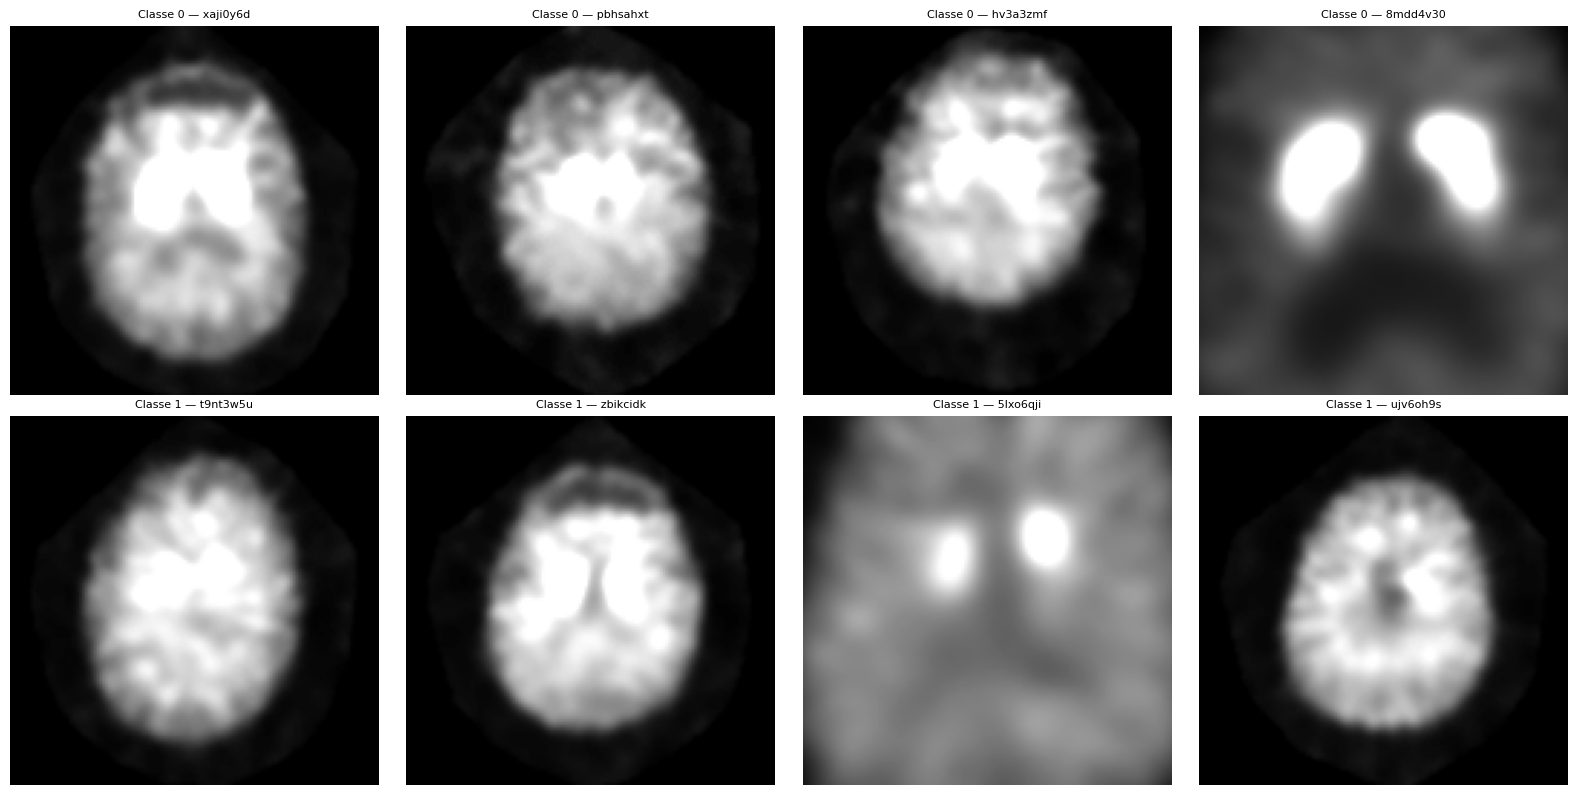

In [11]:
# Recherche visuelle d'un signal determinant

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# 4 exemples de chaque classe, coupe axiale centrale
class0_uids = labels_df_filtered[labels_df_filtered["is_pathologic"] == 0]["uid"].values[:4]
class1_uids = labels_df_filtered[labels_df_filtered["is_pathologic"] == 1]["uid"].values[:4]

for col, uid in enumerate(class0_uids):
    img = nib.load(os.path.join(FINAL_DIR, f"{uid}.nii.gz")).get_fdata()
    z = img.shape[2] // 2
    vmin, vmax = np.percentile(img, [1, 99])
    axes[0][col].imshow(img[:, :, z].T, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
    axes[0][col].set_title(f"Classe 0 — {uid}", fontsize=8)
    axes[0][col].axis("off")

for col, uid in enumerate(class1_uids):
    img = nib.load(os.path.join(FINAL_DIR, f"{uid}.nii.gz")).get_fdata()
    z = img.shape[2] // 2
    vmin, vmax = np.percentile(img, [1, 99])
    axes[1][col].imshow(img[:, :, z].T, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
    axes[1][col].set_title(f"Classe 1 — {uid}", fontsize=8)
    axes[1][col].axis("off")

plt.tight_layout()
plt.show()

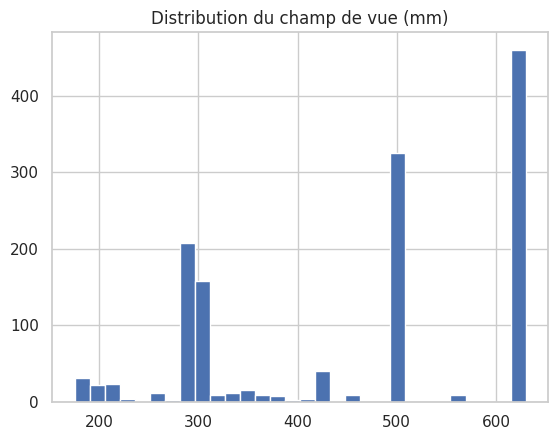

count    1362.000000
mean      461.128357
std       148.540207
min       175.644165
25%       306.892792
50%       498.607330
75%       629.760010
max       629.760010
Name: max_fov_mm, dtype: float64


In [11]:
# Exploration qualite
# quantifier combien de fichiers sont "déjà zoomés" vs "cerveau entier"

import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import os

def load_nifti_from_zip(zip_path, member_name, tmp_dir="/content/_tmp_nii"):
    os.makedirs(tmp_dir, exist_ok=True)
    tmp_path = os.path.join(tmp_dir, os.path.basename(member_name))
    with zipfile.ZipFile(zip_path) as z:
        with z.open(member_name) as src, open(tmp_path, "wb") as dst:
            dst.write(src.read())
    return nib.load(tmp_path)

OUTER_ZIP = f"{DATA_DIR}/DaTScan_data.zip"  # remets le vrai nom si besoin

fov_records = []
with zipfile.ZipFile(OUTER_ZIP) as z:
    members = [n for n in z.namelist() if n.endswith(".nii.gz")]

for name in members:
    img = load_nifti_from_zip(OUTER_ZIP, name)
    shape = img.shape[:3]
    voxel = img.header.get_zooms()[:3]
    fov = tuple(s * v for s, v in zip(shape, voxel))
    fov_records.append({"filename": name, "max_fov_mm": max(fov)})

fov_df = pd.DataFrame(fov_records)
fov_df["max_fov_mm"].hist(bins=30)
plt.title("Distribution du champ de vue (mm)")
plt.show()

print(fov_df["max_fov_mm"].describe())

In [12]:
print(fov_df["max_fov_mm"].value_counts().head(10))

max_fov_mm
629.760010    460
498.607330    325
294.399994    207
306.892792    149
421.845764     26
187.938553     25
423.000305     13
256.000000     10
459.641602      9
565.708801      9
Name: count, dtype: int64


In [13]:
fov_df["uid"] = fov_df["filename"].str.replace(".nii.gz", "", regex=False)
merged = fov_df.merge(labels_df_filtered, on="uid")

print(merged.groupby("is_pathologic")["max_fov_mm"].describe())

               count        mean         std         min         25%  \
is_pathologic                                                          
0.0            615.0  443.163910  152.476669  175.644165  294.399994   
1.0            747.0  475.918335  143.643356  187.938553  306.892792   

                     50%        75%        max  
is_pathologic                                   
0.0            498.60733  629.76001  629.76001  
1.0            498.60733  629.76001  629.76001  


In [14]:
# Répartition des groupes de FOV principaux par classe
top_fovs = merged["max_fov_mm"].value_counts().head(4).index

for fov_val in top_fovs:
    subset = merged[merged["max_fov_mm"] == fov_val]
    print(f"\nFOV = {fov_val:.1f}mm ({len(subset)} fichiers)")
    print(subset["is_pathologic"].value_counts(normalize=True))


FOV = 629.8mm (460 fichiers)
is_pathologic
1.0    0.593478
0.0    0.406522
Name: proportion, dtype: float64

FOV = 498.6mm (325 fichiers)
is_pathologic
1.0    0.581538
0.0    0.418462
Name: proportion, dtype: float64

FOV = 294.4mm (207 fichiers)
is_pathologic
1.0    0.502415
0.0    0.497585
Name: proportion, dtype: float64

FOV = 306.9mm (149 fichiers)
is_pathologic
0.0    0.536913
1.0    0.463087
Name: proportion, dtype: float64


In [15]:
def crop_to_fixed_physical_size(img, physical_size_mm=200, margin_ratio=0.1):
    """Recadre un volume au centre du signal, sur une taille physique fixe (en mm),
    peu importe le FOV d'origine — pour rendre les volumes comparables entre protocoles."""
    data = img.get_fdata().astype(np.float32)
    voxel_size = np.array(img.header.get_zooms()[:3])

    # Bounding box du signal (comme avant)
    threshold = np.percentile(data, 1) + 1e-6
    mask = data > threshold
    if not mask.any():
        center = np.array(data.shape) // 2
    else:
        coords = np.array(np.nonzero(mask))
        center = coords.mean(axis=1).astype(int)

    # Taille du crop en voxels, dérivée de la taille physique voulue
    crop_size_voxels = (physical_size_mm / voxel_size).astype(int)

    crop_slices = []
    for axis in range(3):
        half = crop_size_voxels[axis] // 2
        start = max(center[axis] - half, 0)
        end = min(center[axis] + half, data.shape[axis])
        crop_slices.append(slice(start, end))

    cropped = data[tuple(crop_slices)]
    return cropped

In [16]:
def crop_and_resize_v2(img, physical_size_mm=200, target_shape=(128, 128, 128)):
    cropped = crop_to_fixed_physical_size(img, physical_size_mm=physical_size_mm)
    final = center_crop_or_pad(cropped, target_shape)  # fonction déjà définie précédemment
    return final

In [18]:
def center_crop_or_pad(data, target_shape):
    """Recadre ou complète (pad) un volume 3D pour atteindre exactement target_shape,
    centré sur les axes."""
    crop_slices = []
    for axis in range(3):
        size = data.shape[axis]
        target = target_shape[axis]
        if size > target:
            start = (size - target) // 2
            crop_slices.append(slice(start, start + target))
        else:
            crop_slices.append(slice(0, size))
    cropped = data[tuple(crop_slices)]

    pad_widths = []
    for axis in range(3):
        size = cropped.shape[axis]
        target = target_shape[axis]
        total_pad = max(target - size, 0)
        pad_before = total_pad // 2
        pad_after = total_pad - pad_before
        pad_widths.append((pad_before, pad_after))

    padded = np.pad(cropped, pad_widths, mode="constant", constant_values=0)
    return padded

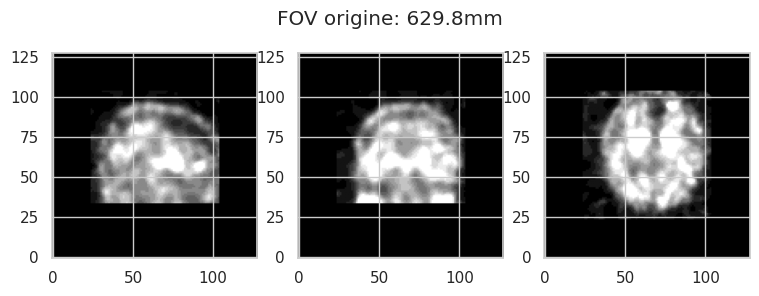

In [19]:
test_files = {
    629.8: "04x0qzfh.nii.gz",  # à adapter avec un vrai uid de ce groupe si différent
}
# ajoute un fichier de chaque groupe (498.6, 294.4, 306.9) si tu en as les uids sous la main

for fov, name in test_files.items():
    img = load_nifti_from_zip(OUTER_ZIP, name)  # ou nib.load depuis resampled_v2 si déjà resamplé
    result = crop_and_resize_v2(img, physical_size_mm=200, target_shape=(128,128,128))

    fig, axes = plt.subplots(1, 3, figsize=(9,3))
    x,y,z = result.shape
    vmin, vmax = np.percentile(result, [1,99])
    axes[0].imshow(result[x//2,:,:].T, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
    axes[1].imshow(result[:,y//2,:].T, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
    axes[2].imshow(result[:,:,z//2].T, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
    plt.suptitle(f"FOV origine: {fov}mm")
    plt.show()

In [23]:
for fov_val in [498.6, 294.4, 306.9]:
    example = merged[np.isclose(merged["max_fov_mm"], fov_val, atol=0.5)]["uid"].iloc[0]
    print(f"FOV {fov_val}mm -> exemple: {example}")

FOV 498.6mm -> exemple: 0224wk0y
FOV 294.4mm -> exemple: 085rntdr
FOV 306.9mm -> exemple: 07gbasf5


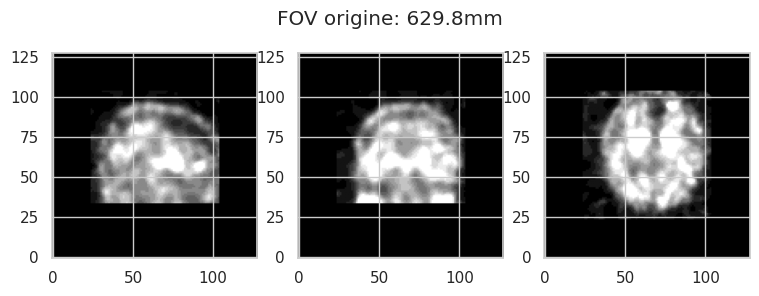

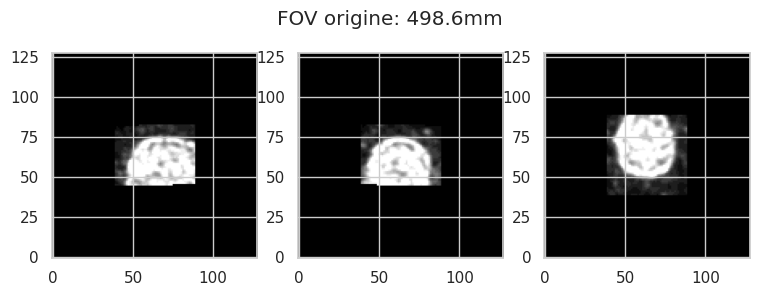

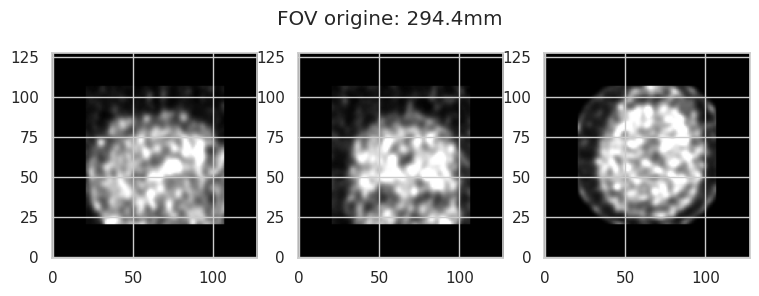

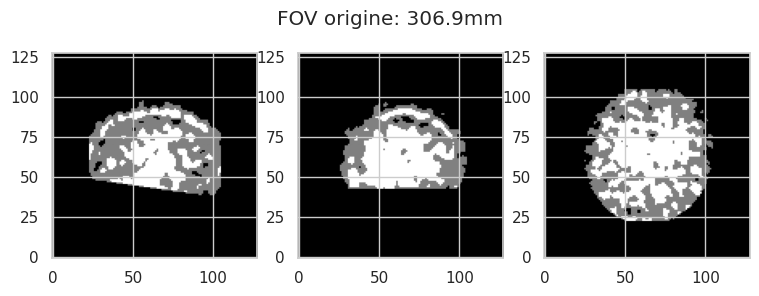

In [24]:


test_files = {
    629.8: "04x0qzfh.nii.gz",
    498.6: "0224wk0y.nii.gz",   # remplace par le vrai uid affiché
    294.4: "085rntdr.nii.gz",   # idem
    306.9: "07gbasf5.nii.gz",   # idem
}


for fov, name in test_files.items():
    img = load_nifti_from_zip(OUTER_ZIP, name)
    result = crop_and_resize_v2(img, physical_size_mm=200, target_shape=(128,128,128))

    fig, axes = plt.subplots(1, 3, figsize=(9,3))
    x,y,z = result.shape
    vmin, vmax = np.percentile(result, [1,99])
    axes[0].imshow(result[x//2,:,:].T, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
    axes[1].imshow(result[:,y//2,:].T, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
    axes[2].imshow(result[:,:,z//2].T, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
    plt.suptitle(f"FOV origine: {fov}mm")
    plt.show()

In [25]:
# Test pour voir si l'image est deja retravaillee (cadre, flitre...)

example_306 = merged[np.isclose(merged["max_fov_mm"], 306.9, atol=0.5)]["uid"].iloc[0]
img_306 = load_nifti_from_zip(OUTER_ZIP, f"{example_306}.nii.gz")
data_306 = img_306.get_fdata()

print("dtype:", img_306.get_data_dtype())
print("Valeurs uniques (max 20):", np.unique(data_306)[:20])
print("Nombre de valeurs uniques:", len(np.unique(data_306)))
print("Min/Max:", data_306.min(), data_306.max())

dtype: uint16
Valeurs uniques (max 20): [0. 1. 2. 3. 4. 5. 6. 7.]
Nombre de valeurs uniques: 8
Min/Max: 0.0 7.0


In [26]:
for fov_val in [629.8, 498.6, 294.4]:
    uid = merged[np.isclose(merged["max_fov_mm"], fov_val, atol=0.5)]["uid"].iloc[0]
    img = load_nifti_from_zip(OUTER_ZIP, f"{uid}.nii.gz")
    print(f"FOV {fov_val}mm — uid {uid} — shape origine: {img.shape} — spacing origine: {img.header.get_zooms()[:3]}")

FOV 629.8mm — uid 04x0qzfh — shape origine: (256, 256, 256) — spacing origine: (np.float32(2.46), np.float32(2.46), np.float32(2.46))
FOV 498.6mm — uid 0224wk0y — shape origine: (128, 128, 38) — spacing origine: (np.float32(3.8953698), np.float32(3.8953698), np.float32(3.9))
FOV 294.4mm — uid 085rntdr — shape origine: (128, 128, 128) — spacing origine: (np.float32(2.3), np.float32(2.3), np.float32(2.3))


In [27]:
import zipfile

with zipfile.ZipFile(OUTER_ZIP) as z:
    members = [n for n in z.namelist() if n.endswith(".nii.gz")]

suspect_files = []
for name in members:
    img = load_nifti_from_zip(OUTER_ZIP, name)
    data = img.get_fdata()
    n_unique = len(np.unique(data))
    if n_unique < 50:  # seuil arbitraire mais large ; une vraie image DatScan a des milliers de valeurs uniques
        suspect_files.append({"filename": name, "n_unique_values": n_unique, "dtype": str(img.get_data_dtype())})

suspect_df = pd.DataFrame(suspect_files)
print(f"{len(suspect_df)} fichiers suspects sur {len(members)}")
suspect_df.head(20)

201 fichiers suspects sur 1362


,filename,n_unique_values,dtype
0,07gbasf5.nii.gz,8,uint16
1,09vs9kkh.nii.gz,43,uint16
2,0i6g61pc.nii.gz,12,uint16
3,0j1oulwo.nii.gz,7,uint16
4,118qqvae.nii.gz,49,uint16
5,12pgyme6.nii.gz,33,uint16
6,146vey0a.nii.gz,11,uint16
7,1jrj5xfe.nii.gz,11,uint16
8,1sa3y5t3.nii.gz,15,uint16
9,1xj7wwud.nii.gz,15,uint16


['48nysj5y.nii.gz', 'jmk4x1fd.nii.gz', 'el8mwob4.nii.gz', 'ei3zrrhf.nii.gz', 'yb7w8p74.nii.gz']


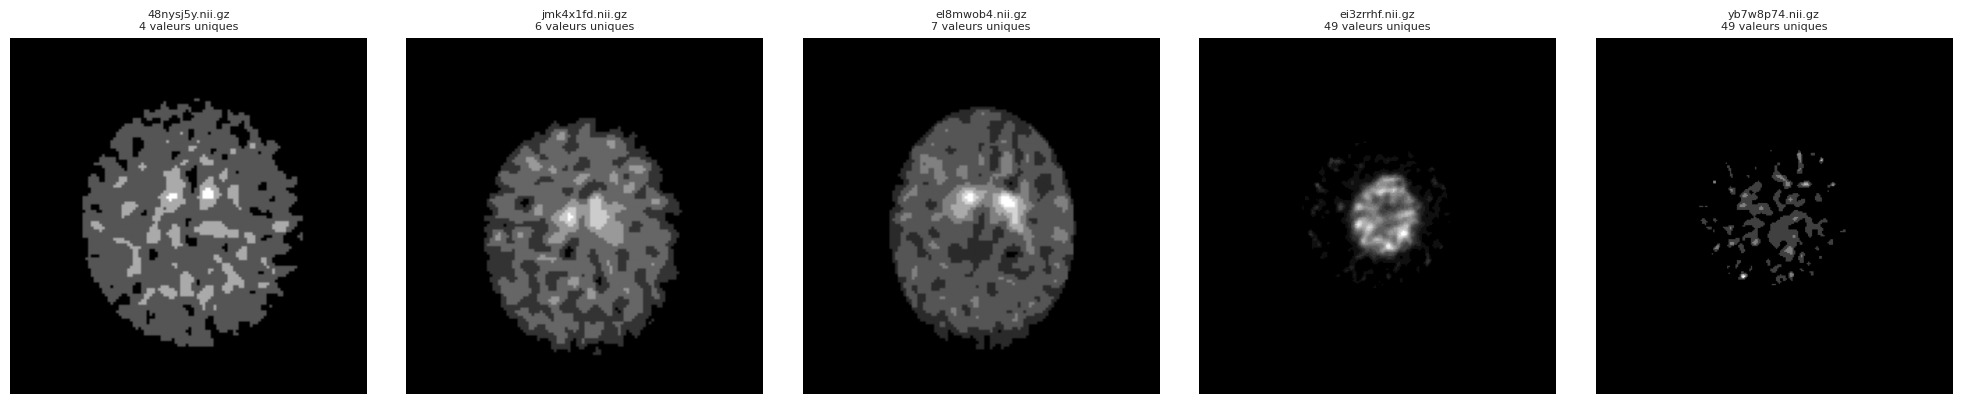

In [28]:
examples_to_check = suspect_df.sort_values("n_unique_values")["filename"].iloc[[0, 5, 10, -5, -1]].tolist()
print(examples_to_check)

fig, axes = plt.subplots(1, len(examples_to_check), figsize=(4*len(examples_to_check), 4))

for ax, name in zip(axes, examples_to_check):
    img = load_nifti_from_zip(OUTER_ZIP, name)
    data = img.get_fdata()
    z = data.shape[2] // 2
    n_unique = len(np.unique(data))
    ax.imshow(data[:, :, z].T, cmap="gray", origin="lower")
    ax.set_title(f"{name}\n{n_unique} valeurs uniques", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Test : Normalisation de percentile


In [29]:
!pip install -q antspyx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 21.7 MB/s eta 0:00:00


In [34]:
!pip install -q nilearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 126.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.


In [35]:
import ants
from nilearn import datasets
import nibabel as nib
import numpy as np

mni_img = datasets.load_mni152_template(resolution=1)
nib.save(mni_img, "/content/mni152_template.nii.gz")

template = ants.image_read("/content/mni152_template.nii.gz")
print("Template shape:", template.shape, "spacing:", template.spacing)

Template shape: (197, 233, 189) spacing: (1.0, 1.0, 1.0)


In [31]:
# Fonction de recalage - Affine

def register_and_normalize(zip_path, member_name, template, tmp_dir="/content/_tmp_reg"):
    """Recale un volume DatScan vers le template MNI152 (affine) et normalise
    son intensité par percentile."""
    os.makedirs(tmp_dir, exist_ok=True)

    # Charger le fichier depuis le zip
    tmp_in_path = os.path.join(tmp_dir, os.path.basename(member_name))
    with zipfile.ZipFile(zip_path) as z:
        with z.open(member_name) as src, open(tmp_in_path, "wb") as dst:
            dst.write(src.read())

    moving = ants.image_read(tmp_in_path)

    # Recalage affine (rotation, échelle, translation) vers le template
    reg = ants.registration(fixed=template, moving=moving, type_of_transform="Affine")
    registered = reg["warpedmovout"]

    data = registered.numpy().astype(np.float32)

    # Normalisation d'intensité par percentile, propre à cette image
    vmin, vmax = np.percentile(data, [1, 99])
    data_norm = np.clip((data - vmin) / (vmax - vmin + 1e-6), 0, 1)

    return data_norm

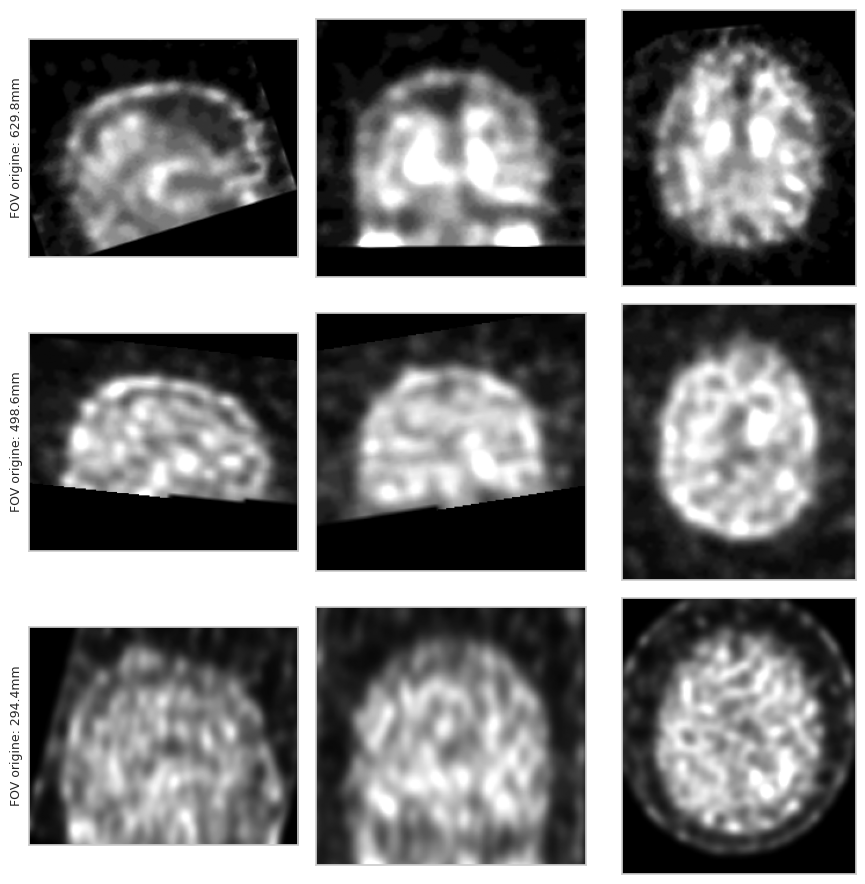

In [36]:
# Test visuel sur un fichier de chaque groupe FOV

import zipfile, os
import matplotlib.pyplot as plt

test_files = {
    629.8: "04x0qzfh.nii.gz",
    498.6: "0224wk0y.nii.gz",
    294.4: "085rntdr.nii.gz",
}

fig, axes = plt.subplots(len(test_files), 3, figsize=(9, 3 * len(test_files)))

for row, (fov, name) in enumerate(test_files.items()):
    result = register_and_normalize(OUTER_ZIP, name, template)
    x, y, z = result.shape

    axes[row][0].imshow(result[x // 2, :, :].T, cmap="gray", origin="lower", vmin=0, vmax=1)
    axes[row][1].imshow(result[:, y // 2, :].T, cmap="gray", origin="lower", vmin=0, vmax=1)
    axes[row][2].imshow(result[:, :, z // 2].T, cmap="gray", origin="lower", vmin=0, vmax=1)
    axes[row][0].set_ylabel(f"FOV origine: {fov}mm", fontsize=9)
    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()